# Predicting Company Bankruptcies
## End to End Machine learning Pipeline
This project aims to predict whether a company will go bankrupt based on financial indicators using machine learning techniques.

## Project Overview

This project aims to predict company bankruptcy using financial indicators.

The objective is to build a reliable machine learning model that can help in:
- Risk assessment
- Financial decision-making
- Early identification of high-risk companies

## Import Libraries
We import all necessary libraries for data processing, visualization, model building, and evaluation.

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import roc_curve,auc
import shap
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import display, HTML

from sklearn.svm import SVC
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
import joblib

In [2]:
#  Loading the Dataset
df = pd.read_csv("Bankruptcies.csv")

## Data Preview
Displaying the first few rows of the dataset to understand its structure and feature values.
This helps verify that the dataset is loaded correctly.

In [3]:
pd.set_option('display.max_columns',None)

In [4]:
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,1.256969e-04,0.0,0.458143,0.000725,0.0,0.147950,0.147950,0.147950,0.169141,0.311664,0.017560,0.095921,0.138736,0.022102,0.848195,0.688979,0.688979,0.217535,4.980000e+09,0.000327,0.263100,0.363725,0.002259,0.001208,0.629951,0.021266,0.207576,0.792424,0.005024,0.390284,0.006479,0.095885,0.137757,0.398036,0.086957,0.001814,0.003487,1.820926e-04,1.165007e-04,0.032903,0.034164,0.392913,0.037135,0.672775,0.166673,0.190643,0.004094,0.001997,1.473360e-04,0.147308,0.334015,0.276920,0.001036,0.676269,0.721275,0.339077,0.025592,0.903225,0.002022,0.064856,7.010000e+08,6.550000e+09,0.593831,4.580000e+08,0.671568,0.424206,0.676269,0.339077,0.126549,0.637555,0.458609,0.520382,0.312905,0.118250,0,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,2.897851e-04,0.0,0.461867,0.000647,0.0,0.182251,0.182251,0.182251,0.208944,0.318137,0.021144,0.093722,0.169918,0.022080,0.848088,0.689693,0.689702,0.217620,6.110000e+09,0.000443,0.264516,0.376709,0.006016,0.004039,0.635172,0.012502,0.171176,0.828824,0.005059,0.376760,0.005835,0.093743,0.168962,0.397725,0.064468,0.001286,0.004917,9.360000e+09,7.190000e+08,0.025484,0.0068

### Insights

- The dataset contains financial indicators such as ROA, profit margins, and expense ratios  
- All features are numerical  
- Target variable: **Bankrupt? (1 = Yes, 0 = No)**  

These features will be used to predict company bankruptcy.

In [5]:
## Dataset Shape
df.shape

(6819, 96)

##### The dataset contains 6819 rows and 96 columns.
##### This indicates a high-dimensional dataset with many financial features.

## Data Information
- All features are numerical  
- No missing values present  
- Target variable is binary (Bankrupt or Not)  

This simplifies preprocessing and model training.

In [6]:
##Data Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

## Statistical Summary

We analyze descriptive statistics to understand feature distribution.

In [7]:
df.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6.819000e+03,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6819.000000,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,0.781381,1.995347e+09,1.950427e+09,0.467431,1.644801e+07,0.11

### 
- Most feature values lie between **0 and 1**  
- Data appears normalized  
- Low variation in many features  

This indicates stable and well-scaled financial data.

In [8]:
## Missing Values Check
pd.set_option('display.max_rows',None)
df.isnull().sum()

Bankrupt?                                                   0
 ROA(C) before interest and depreciation before interest    0
 ROA(A) before interest and % after tax                     0
 ROA(B) before interest and depreciation after tax          0
 Operating Gross Margin                                     0
 Realized Sales Gross Margin                                0
 Operating Profit Rate                                      0
 Pre-tax net Interest Rate                                  0
 After-tax net Interest Rate                                0
 Non-industry income and expenditure/revenue                0
 Continuous interest rate (after tax)                       0
 Operating Expense Rate                                     0
 Research and development expense rate                      0
 Cash flow rate                                             0
 Interest-bearing debt interest rate                        0
 Tax rate (A)                                               0
 Net Val

###  Insights

- No missing values found  
- No need for imputation  
- Data is complete and reliable 

In [9]:
## Duplicate Check
df.duplicated().sum()

np.int64(0)

In [10]:
print("Total duplicated rows:",df.duplicated().sum())

Total duplicated rows: 0


## Target Variable Analysis

We analyze the distribution of the target variable (Bankrupt?) to understand class imbalance in the dataset.

This helps in identifying whether preprocessing techniques like undersampling or oversampling are required.

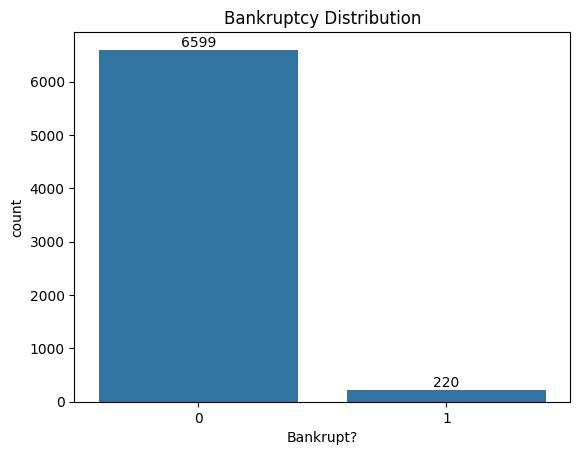

In [11]:
count_plot = sns.countplot(x=df["Bankrupt?"])
count_plot.bar_label(count_plot.containers[0])

plt.title("Bankruptcy Distribution")
plt.show()

###  Insights

- Non-Bankrupt companies: **6599**
- Bankrupt companies: **220**

This shows that the dataset is **highly imbalanced**.

 Impact:
- Model may become biased towards majority class  
- Requires handling imbalance using techniques like undersampling . 

## Bankruptcy Percentage

We visualize the percentage distribution of bankrupt vs non-bankrupt companies.

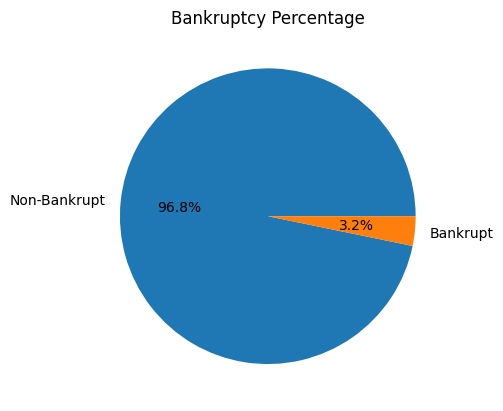

In [12]:
plt.pie(df["Bankrupt?"].value_counts(),
        labels=["Non-Bankrupt","Bankrupt"],
        autopct="%1.1f%%")

plt.title("Bankruptcy Percentage")
plt.show()

###  Insights

- Non-Bankrupt: **~96.8%**
- Bankrupt: **~3.2%**

This confirms extreme class imbalance.

## Feature Correlation Analysis
We analyze the correlation between financial indicators and the target variable (Bankrupt?).

To focus on the most important features, we select the top features that have the highest correlation with bankruptcy.

This helps in identifying key financial factors influencing bankruptcy risk.

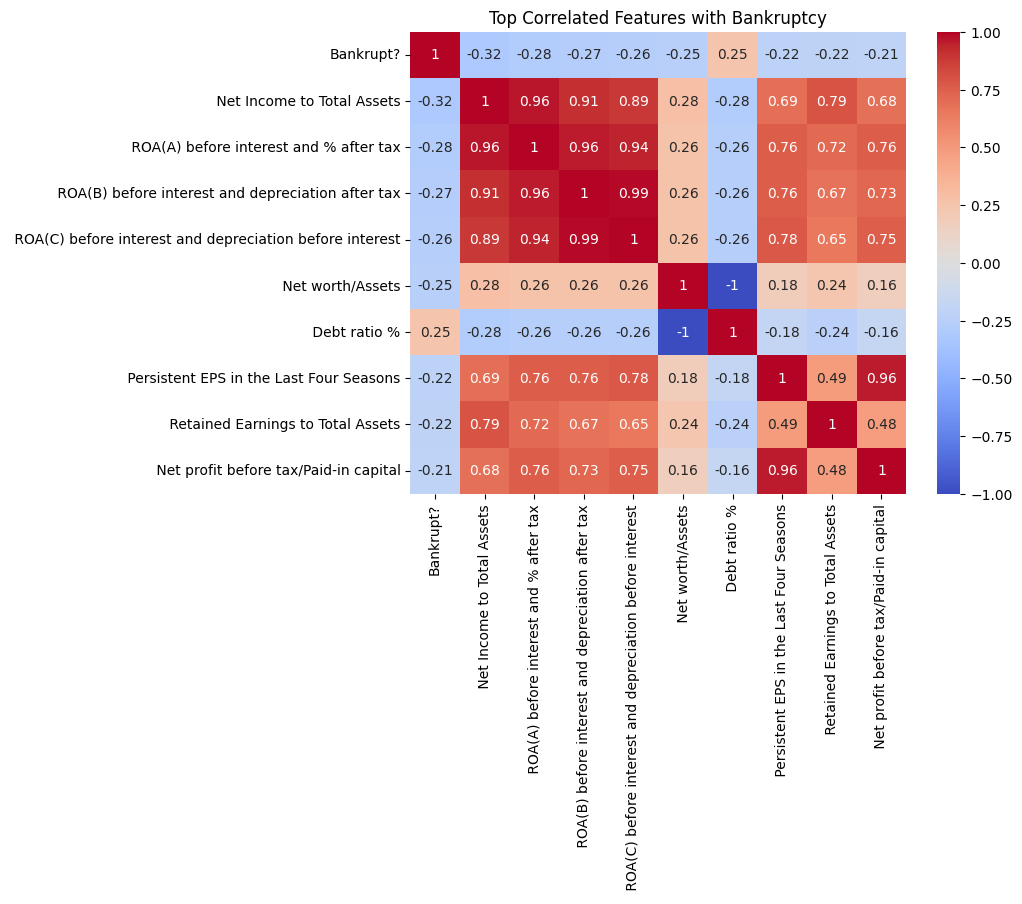

In [13]:
corr = df.corr()

top_features = corr["Bankrupt?"].abs().sort_values(ascending=False).head(10).index

plt.figure(figsize=(8,6))

sns.heatmap(df[top_features].corr(), annot=True, cmap="coolwarm")

plt.title("Top Correlated Features with Bankruptcy")

plt.show()

###  Insights

 Profitability features (ROA, Net Income)show strong negative correlation with bankruptcy  
  Higher profitability reduces bankruptcy risk  

Debt-related features (Debt ratio) show positive correlation  
   Higher debt increases bankruptcy risk  

Net worth / assets also influence bankruptcy  
  Strong financial position lowers risk  

Many features are highly correlated with each other  
  Indicates multicollinearity  

  The correlation analysis confirms that profitability and leverage are key factors in predicting bankruptcy.


## Top Indicators Affecting Bankruptcy

We identify the most important financial indicators based on their correlation with the target variable (Bankrupt?).

Only the top features with the highest correlation values are selected.

This helps in understanding which financial factors contribute most to bankruptcy prediction.

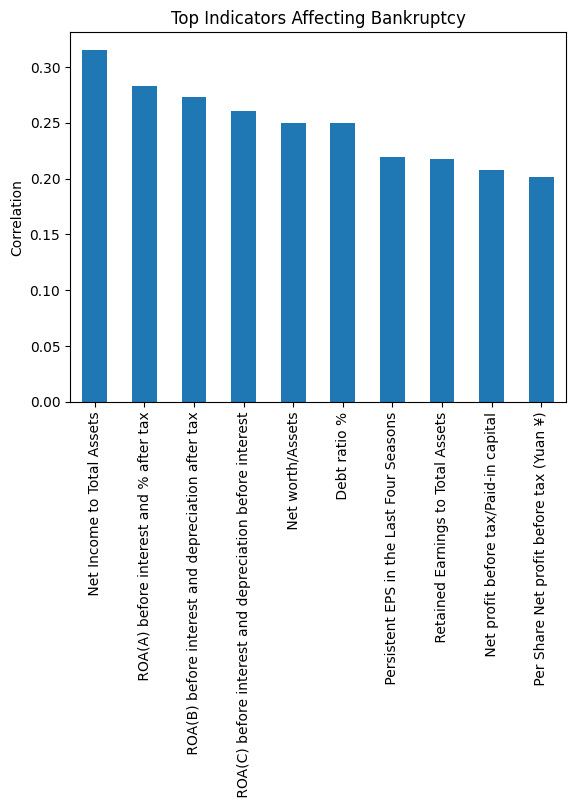

Net Income to Total Assets                                 0.315457
ROA(A) before interest and % after tax                     0.282941
ROA(B) before interest and depreciation after tax          0.273051
ROA(C) before interest and depreciation before interest    0.260807
Net worth/Assets                                           0.250161
Debt ratio %                                               0.250161
Persistent EPS in the Last Four Seasons                    0.219560
Retained Earnings to Total Assets                          0.217779
Net profit before tax/Paid-in capital                      0.207857
Per Share Net profit before tax (Yuan ¥)                   0.201395
Name: Bankrupt?, dtype: float64


In [14]:
top_features = corr["Bankrupt?"].abs().sort_values(ascending=False)[1:11]

top_features.plot(kind="bar")

plt.title("Top Indicators Affecting Bankruptcy")

plt.ylabel("Correlation")

plt.show()
print(top_features)

###  Interpretation

- The highest correlation is observed for **Net Income to Total Assets**, indicating that profitability is the strongest predictor of bankruptcy.

- Multiple **ROA (Return on Assets)** features appear in the top indicators  
  → This confirms that efficient use of assets plays a major role in company survival.

- **Debt ratio** is also significant  
  → Higher debt increases the likelihood of bankruptcy.

- **Earnings-related features (EPS, Retained Earnings)** indicate long-term financial stability  
  → Companies with stable earnings are less likely to fail.

## Debt Ratio Distribution by Bankruptcy

We analyze how debt ratio differs between bankrupt and non-bankrupt companies.

Debt ratio is a key financial indicator that reflects a company's financial leverage

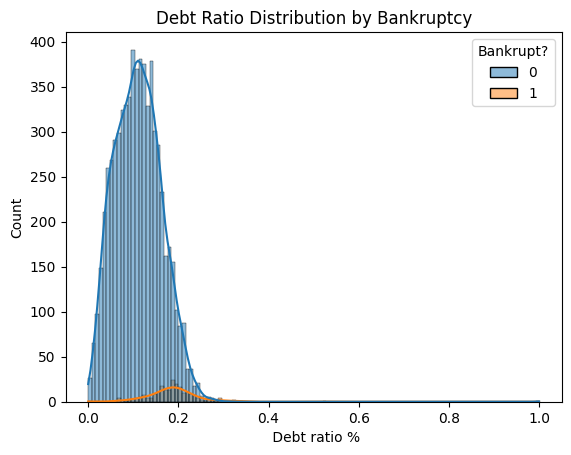

In [15]:
sns.histplot(
data=df,
x=" Debt ratio %",
hue="Bankrupt?",
kde=True
)

plt.title("Debt Ratio Distribution by Bankruptcy")

plt.show()

###  Insights

- Most companies have a low to moderate debt ratio  
- Bankrupt companies tend to have slightly higher debt ratios  
- Distribution shows overlap, but higher debt increases risk

Debt ratio is an important risk indicator but not sufficient alone for prediction.


## Operating Profit Rate Distribution

We analyze the distribution of operating profit rate across companies.

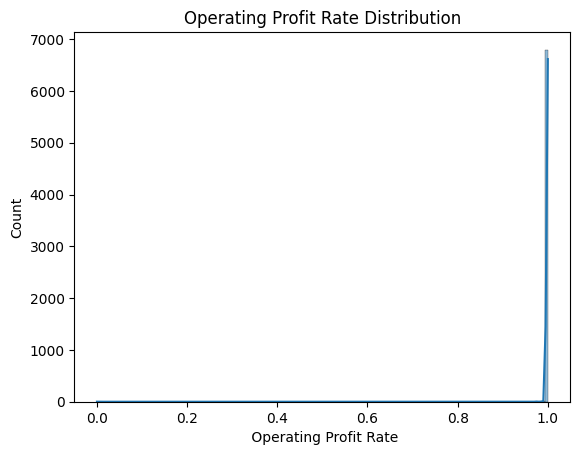

In [16]:
sns.histplot(df[" Operating Profit Rate"],kde =True)
plt.title("Operating Profit Rate Distribution")
plt.show()

###  Insights

- Most values are concentrated near 1  
- Very low variation observed  

### Observation

This feature may have low variance and limited predictive power.

### Conclusion

Operating profit rate alone may not strongly differentiate bankrupt vs non-bankrupt companies.

## Profit vs Asset Growth Relationship

We analyze the relationship between profit and asset growth, categorized by bankruptcy status.

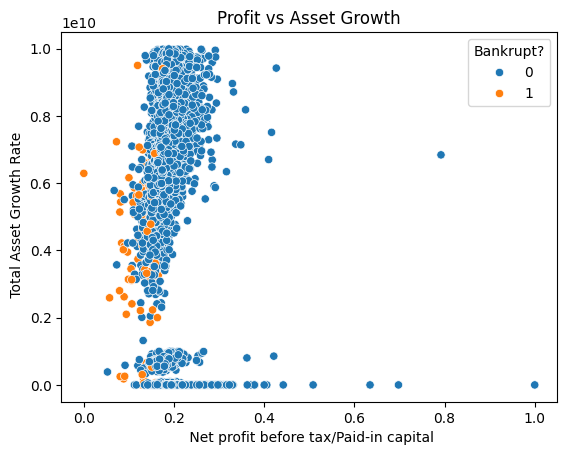

In [17]:
sns.scatterplot(
    x=df[" Net profit before tax/Paid-in capital"],
    y=df[" Total Asset Growth Rate"],
    hue=df["Bankrupt?"]
)

plt.title("Profit vs Asset Growth")
plt.show()

### Insights

- Non-bankrupt companies are more densely clustered  
- Bankrupt companies are scattered and inconsistent  
- No strong linear relationship observed

## Profitability vs Bankruptcy

We compare profit distribution between bankrupt and non-bankrupt companies.

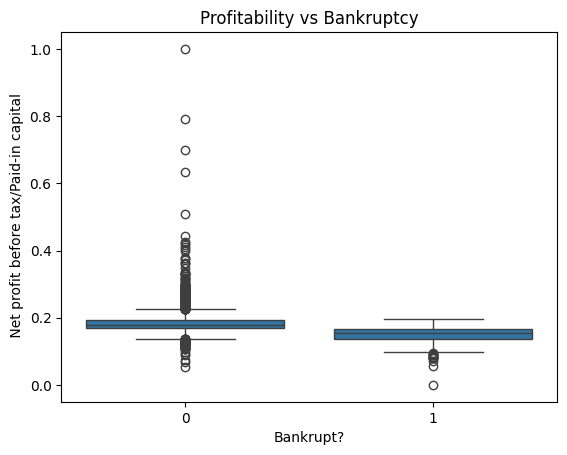

In [18]:
sns.boxplot(
    x=df["Bankrupt?"],
    y=df[" Net profit before tax/Paid-in capital"]
)

plt.title("Profitability vs Bankruptcy")

plt.show()

###  Insights

- Non-bankrupt companies have higher median profit  
- Bankrupt companies show lower profit levels  
- Outliers are present in both categories  

Profitability is a strong indicator of bankruptcy risk.


## Gross Profit Distribution by Bankruptcy

We analyze how gross profit differs between bankrupt and non-bankrupt companies.

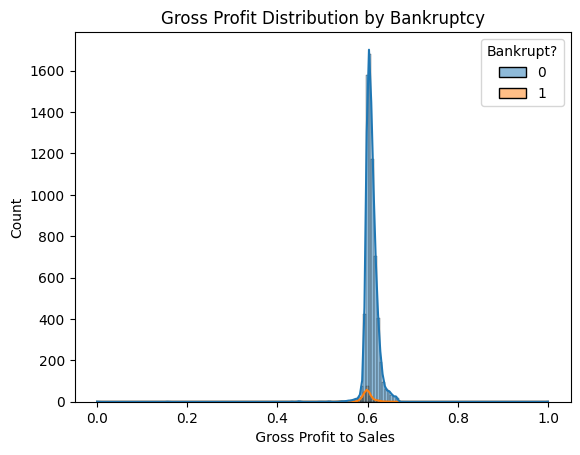

In [19]:
sns.histplot(
    data=df,
    x=" Gross Profit to Sales",
    hue="Bankrupt?",
    kde=True
)

plt.title("Gross Profit Distribution by Bankruptcy")

plt.show()

### Insights

- Most companies have similar gross profit levels  
- Slight differences exist between classes  
- Significant overlap observed  

###  Conclusion

Gross profit alone is not a strong distinguishing feature.

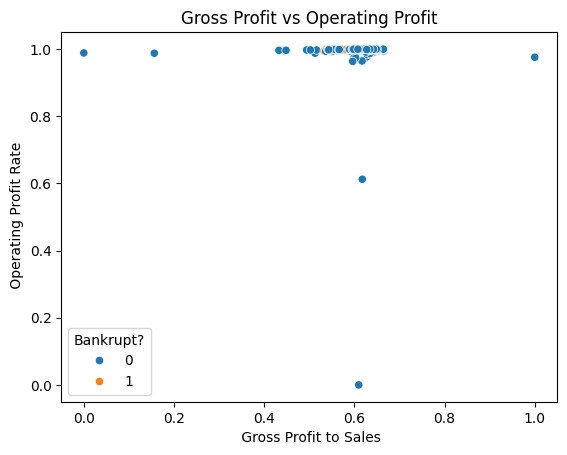

In [20]:
sns.scatterplot(
    x=df[" Gross Profit to Sales"],
    y=df[" Operating Profit Rate"],
    hue=df["Bankrupt?"]
)

plt.title("Gross Profit vs Operating Profit")

plt.show()

## Asset Growth Distribution by Bankruptcy

We analyze how total asset growth differs between bankrupt and non-bankrupt companies.

Asset growth reflects how a company's assets are increasing over time, which indicates business expansion and financial stability.

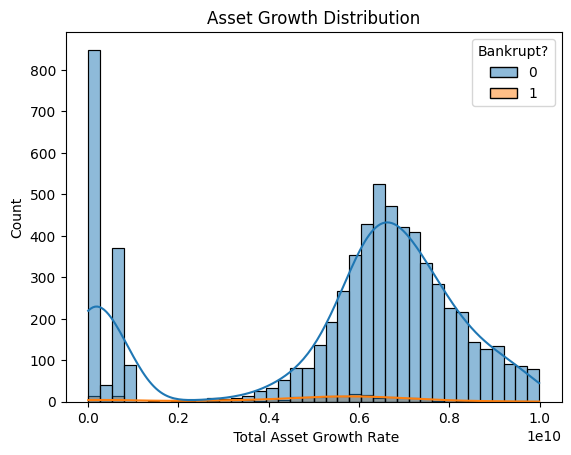

In [21]:
sns.histplot(
    data=df,
    x=" Total Asset Growth Rate",
    hue="Bankrupt?",
    kde=True
)

plt.title("Asset Growth Distribution")
plt.show()

### Insights

- Most companies show moderate asset growth  
- Non-bankrupt companies are more concentrated in stable growth ranges  
- Bankrupt companies are fewer but more scattered  
- Some extreme values (outliers) are present

Asset growth provides useful information about company stability, but it alone is not sufficient to predict bankruptcy accurately.

## Profitability Analysis (ROA Features)

We analyze the distribution of profitability-related features (ROA) in the dataset.

ROA (Return on Assets) measures how efficiently a company generates profit from its assets.

Higher ROA indicates better financial performance and lower risk of bankruptcy.

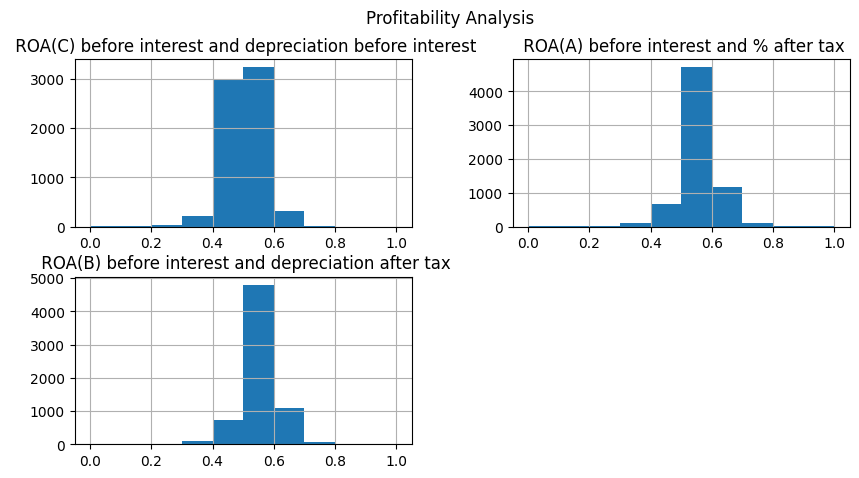

In [22]:
profit_cols = [col for col in df.columns if "ROA" in col]

df[profit_cols].hist(figsize=(10,5))
plt.suptitle("Profitability Analysis")
plt.show()

###  Insights

- Most companies have ROA values concentrated between **0.4 to 0.6**  
- The distribution is fairly consistent across different ROA measures  
- Very few extreme values (outliers) are observed  

- Companies with higher ROA are more efficient in generating profit  
- Lower ROA indicates weak financial performance  
- Profitability is a key factor in determining company stability  

ROA features show stable distribution and are strong indicators of financial health, making them important for bankruptcy prediction.

## Leverage vs Profitability Analysis

We analyze the relationship between debt ratio (leverage) and operating profit rate.

This helps us understand how financial leverage affects company profitability and bankruptcy risk.

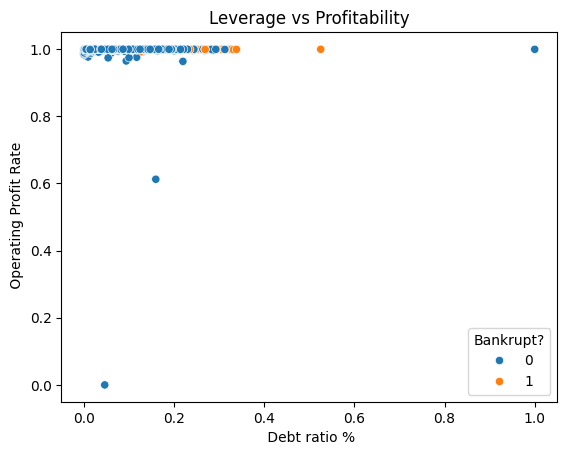

In [23]:
sns.scatterplot(
x=df[" Debt ratio %"],
y=df[" Operating Profit Rate"],
hue=df["Bankrupt?"]
)

plt.title("Leverage vs Profitability")
plt.show()

### Insights

- Most companies have high operating profit values (cluster near 1)  
- Bankrupt companies are scattered and less consistent  
- Some companies with high debt still show high profit  

- High debt does not always lead to low profitability  
- However, unstable profit patterns are more common in bankrupt companies  
- Financial risk increases when high debt is combined with unstable profits  

Leverage and profitability together provide useful insights, but they do not form a clear separation between bankrupt and non-bankrupt companies.

## Average Net Profit Comparison

We compare the average net profit between bankrupt and non-bankrupt companies.

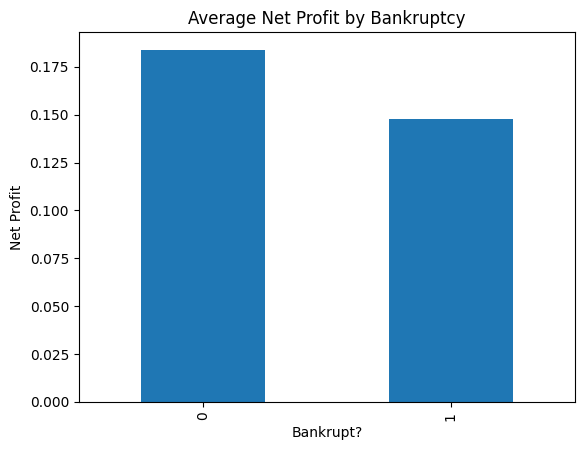

In [24]:
df.groupby("Bankrupt?")[" Net profit before tax/Paid-in capital"].mean().plot(kind="bar")

plt.title("Average Net Profit by Bankruptcy")
plt.ylabel("Net Profit")
plt.show()

### Insights

- Non-bankrupt companies have higher average net profit  
- Bankrupt companies show lower profitability  

- Profitability is directly linked to company survival  
- Lower profits increase financial risk  

Net profit is a strong indicator of bankruptcy, where higher profit reduces the likelihood of failure.

## Debt Ratio vs Bankruptcy

We compare the distribution of debt ratio between bankrupt and non-bankrupt companies using a boxplot.

This helps in understanding how leverage (debt level) impacts bankruptcy risk.

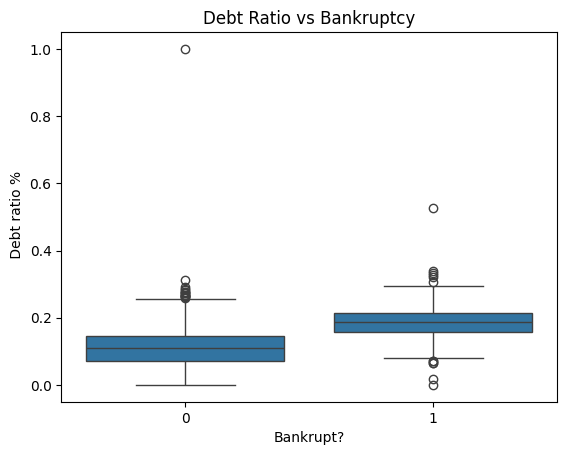

In [25]:
sns.boxplot(
x=df["Bankrupt?"],
y=df[" Debt ratio %"]
)

plt.title("Debt Ratio vs Bankruptcy")

plt.show()

###  Insights

- Bankrupt companies (1) have **higher median debt ratio** compared to non-bankrupt companies (0)  
- The spread of debt ratio is also slightly higher for bankrupt companies  
- Some extreme values (outliers) are present  

- Higher debt increases financial pressure on companies  
- Companies with higher leverage are more likely to face bankruptcy risk  
- Managing debt is critical for financial stability  

Debt ratio is a strong indicator of bankruptcy risk, where higher values are associated with increased likelihood of failure.

## Multivariate Relationship Analysis (Pairplot)

We analyze relationships between multiple financial features simultaneously using a pairplot.

This helps in understanding how different variables interact with each other and how they relate to bankruptcy.

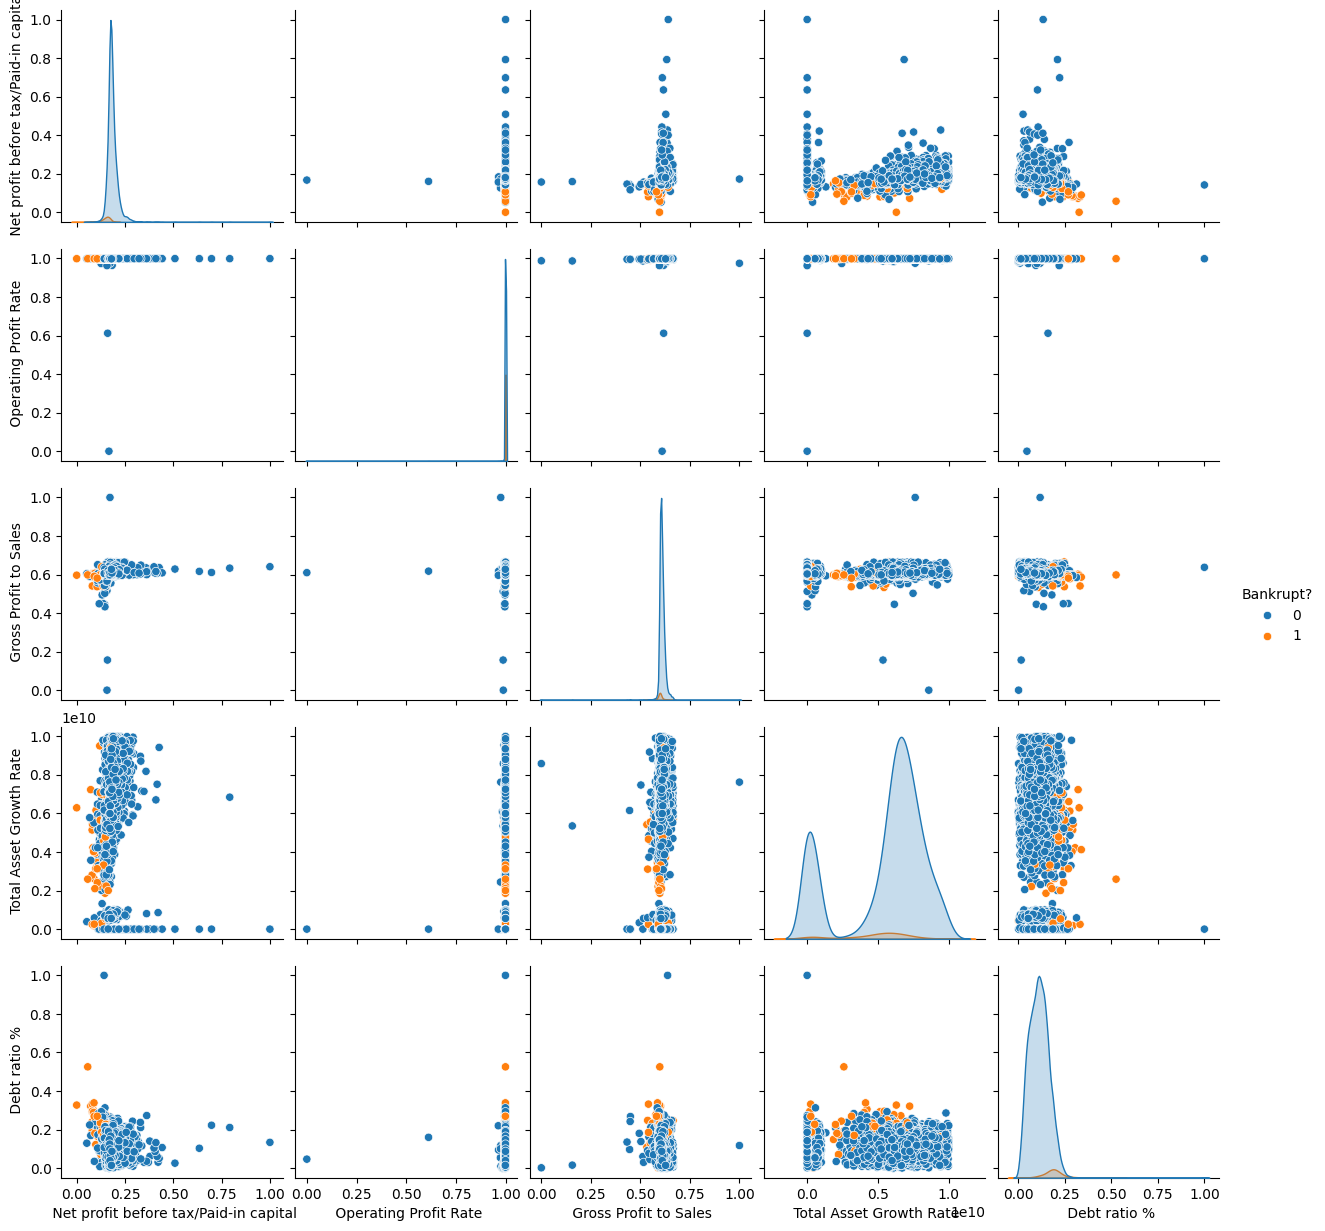

In [26]:
features = [
" Net profit before tax/Paid-in capital",
" Operating Profit Rate",
" Gross Profit to Sales",
" Total Asset Growth Rate",
" Debt ratio %"
]

sns.pairplot(df[features + ["Bankrupt?"]], hue="Bankrupt?")
plt.show()

## Financial Risk Indicator Correlation

We analyze the correlation between key financial risk indicators such as profitability, leverage, and growth.

This helps in understanding how these important features are related to each other.

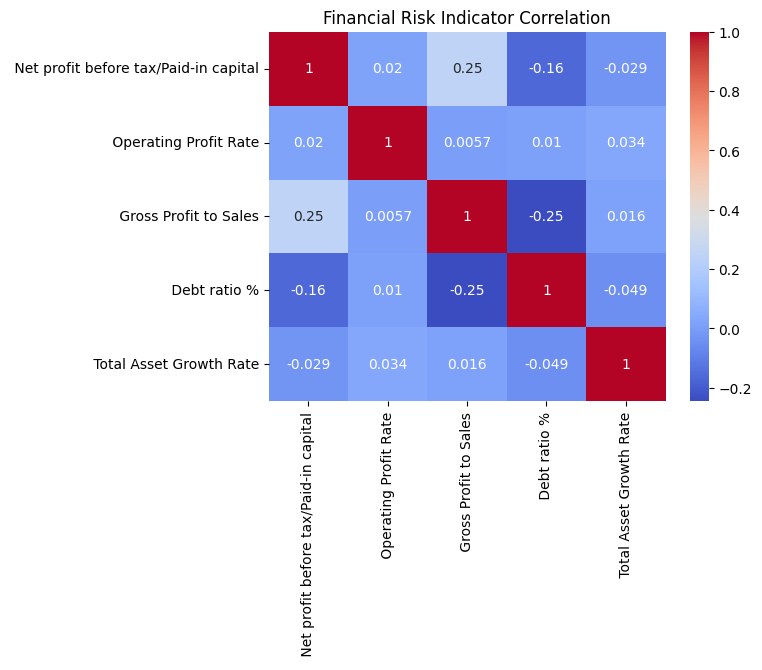

In [27]:
risk_features = [
" Net profit before tax/Paid-in capital",
" Operating Profit Rate",
" Gross Profit to Sales",
" Debt ratio %",
" Total Asset Growth Rate"
]

sns.heatmap(df[risk_features].corr(), annot=True, cmap="coolwarm")

plt.title("Financial Risk Indicator Correlation")

plt.show()

###  Insights

- Most features show **low correlation with each other**  
- Net profit and gross profit have a slight positive relationship  
- Debt ratio shows weak negative correlation with profit-related features  
- Asset growth has very weak correlation with other indicators  
The selected financial risk indicators are not highly correlated, making them useful and complementary features for building a robust bankruptcy prediction model.

## Liquidity Risk Analysis (Current Ratio vs Bankruptcy)

We analyze how liquidity (current ratio) differs between bankrupt and non-bankrupt companies.

The current ratio indicates a company’s ability to meet short-term obligations.

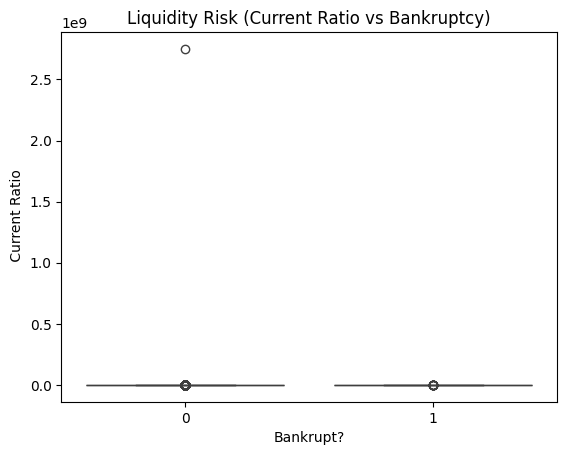

In [28]:
sns.boxplot(
x=df["Bankrupt?"],
y=df[" Current Ratio"]
)

plt.title("Liquidity Risk (Current Ratio vs Bankruptcy)")
plt.show()

###  Insights

- Most values are concentrated near lower ranges  
- One extreme outlier is present  
- No clear separation between bankrupt and non-bankrupt companies 

- Liquidity alone is not a strong indicator of bankruptcy  
- Extreme values may distort analysis  
- Other financial indicators must be considered 

Current ratio provides limited predictive power and should be combined with other features.

## Cash Flow Risk Analysis

We analyze how cash flow relative to total assets differs between bankrupt and non-bankrupt companies.

Cash flow is a critical indicator of a company’s ability to sustain operations.

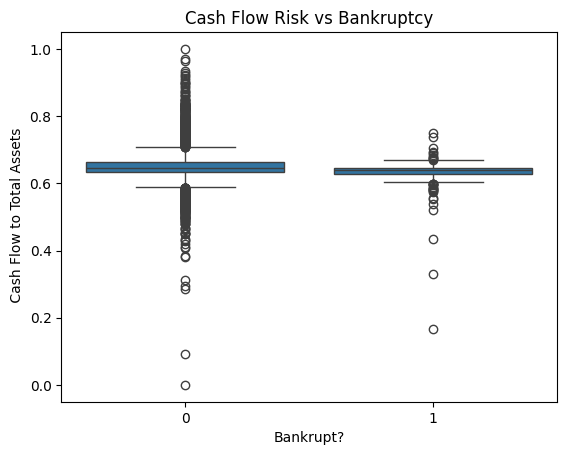

In [29]:
sns.boxplot(
x=df["Bankrupt?"],
y=df[" Cash Flow to Total Assets"]
)

plt.title("Cash Flow Risk vs Bankruptcy")
plt.show()

###  Insights

- Non-bankrupt companies show slightly higher and more stable cash flow  
- Bankrupt companies have lower and more variable values  
- Some outliers are present
  
  Cash flow is an important indicator of financial health and contributes to bankruptcy prediction.

## Net Income Distribution by Bankruptcy

We analyze how net income differs between bankrupt and non-bankrupt companies.

Net income is a key profitability indicator.

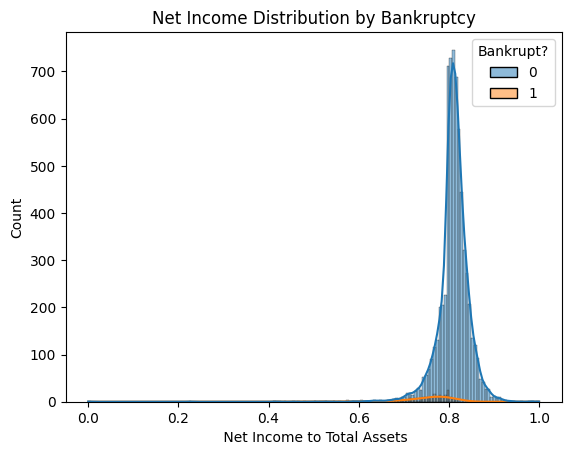

In [30]:
sns.histplot(
data=df,
x=" Net Income to Total Assets",
hue="Bankrupt?",
kde=True
)

plt.title("Net Income Distribution by Bankruptcy")
plt.show()

### Insights

- Most companies are concentrated around higher net income values  
- Bankrupt companies are fewer and slightly shifted  
- Significant overlap exists between the two classes  

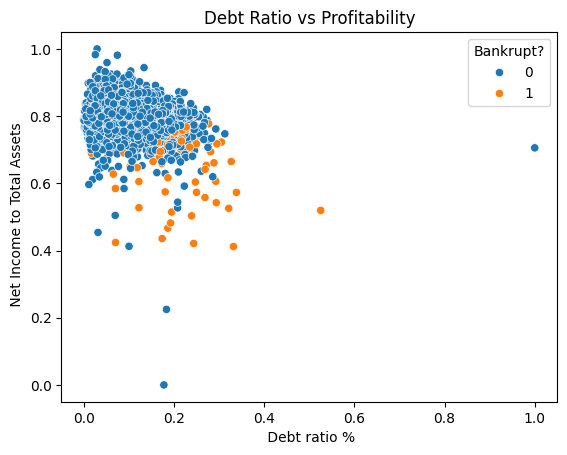

In [31]:
## Debt Ratio vs Profitability
sns.scatterplot(
x=df[" Debt ratio %"],
y=df[" Net Income to Total Assets"],
hue=df["Bankrupt?"]
)

plt.title("Debt Ratio vs Profitability")
plt.show()

## Feature and Target Separation

We separate the dataset into:

- Features (X): All financial indicators  
- Target (y): Bankruptcy status 

In [32]:
X = df.drop("Bankrupt?", axis=1)
y = df["Bankrupt?"]

In [33]:
print(X.shape)
print(y.shape)

(6819, 95)
(6819,)


##### - X contains 95 features  
##### - y contains the target variable (Bankrupt?)  


## Handling Class Imbalance (Undersampling)

The dataset is highly imbalanced, with very few bankrupt companies.

To address this, we use Random Undersampling to balance both classes.

In [34]:
rus = RandomUnderSampler(random_state=42)

In [35]:
X_res, y_res = rus.fit_resample(X, y)

In [36]:
print("Before:\n", y.value_counts())
print("\nAfter:\n", pd.Series(y_res).value_counts())

Before:
 Bankrupt?
0    6599
1     220
Name: count, dtype: int64

After:
 Bankrupt?
0    220
1    220
Name: count, dtype: int64


## Train-Test Split

We split the dataset into training and testing sets.

- Training set → used to train the model  
- Testing set → used to evaluate performance  

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

## Insights

- 80% data used for training  
- 20% data used for testing  

This ensures proper evaluation of model performance.

## Feature Scaling

We apply StandardScaler to normalize the feature values.

This ensures that all features are on the same scale.

In [38]:
scaler = StandardScaler()

X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)

###  Insights

- Features are standardized (mean = 0, std = 1)  
- Improves performance of distance-based models like KNN and SVM  

## Logistic Regression Model

In [39]:
lr = LogisticRegression(random_state = 42)

In [40]:
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [41]:
pred_lr = lr.predict(X_test)

In [42]:
print("Logistic Accuracy:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

Logistic Accuracy: 0.7954545454545454
              precision    recall  f1-score   support

           0       0.85      0.78      0.82        51
           1       0.73      0.81      0.77        37

    accuracy                           0.80        88
   macro avg       0.79      0.80      0.79        88
weighted avg       0.80      0.80      0.80        88



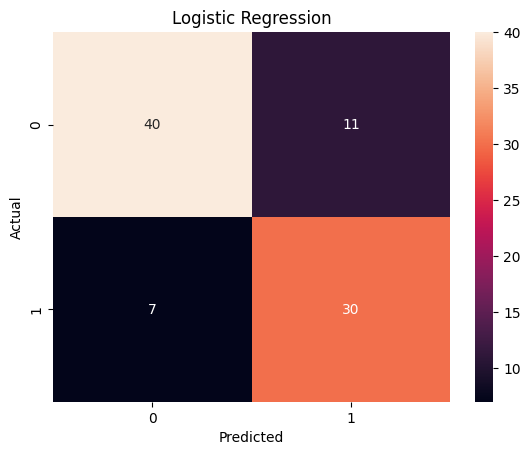

In [43]:
cm_lr = confusion_matrix(y_test, pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Decision Tree Model

In [44]:
dt = DecisionTreeClassifier(random_state = 42)

In [45]:
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [46]:
pred_dt = dt.predict(X_test)

In [47]:
print("Decision Tree Accuracy:", accuracy_score(y_test, pred_dt))
print(classification_report(y_test, pred_dt))

Decision Tree Accuracy: 0.7613636363636364
              precision    recall  f1-score   support

           0       0.83      0.75      0.78        51
           1       0.69      0.78      0.73        37

    accuracy                           0.76        88
   macro avg       0.76      0.76      0.76        88
weighted avg       0.77      0.76      0.76        88



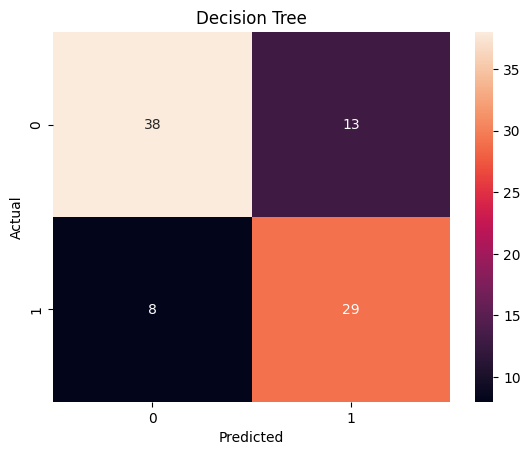

In [48]:
cm_dt = confusion_matrix(y_test, pred_dt)

sns.heatmap(cm_dt, annot=True, fmt='d')
plt.title("Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Decision Tree Model

In [49]:
rf = RandomForestClassifier(random_state = 42)

In [50]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [51]:
pred_rf = rf.predict(X_test)

In [52]:
print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

Random Forest Accuracy: 0.8522727272727273
              precision    recall  f1-score   support

           0       0.90      0.84      0.87        51
           1       0.80      0.86      0.83        37

    accuracy                           0.85        88
   macro avg       0.85      0.85      0.85        88
weighted avg       0.86      0.85      0.85        88



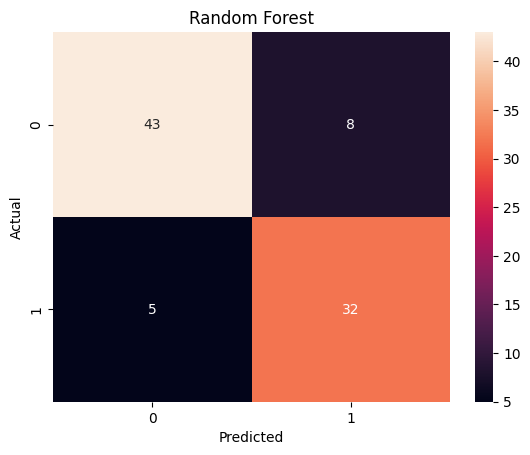

In [53]:
cm_rf = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Support Vector Machine (SVM)

In [54]:
svm = SVC(probability=True)

In [55]:
svm.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [56]:
pred_svm = svm.predict(X_test)

In [57]:
print("SVM Accuracy:", accuracy_score(y_test, pred_svm))
print(classification_report(y_test, pred_svm))

SVM Accuracy: 0.8068181818181818
              precision    recall  f1-score   support

           0       0.89      0.76      0.82        51
           1       0.73      0.86      0.79        37

    accuracy                           0.81        88
   macro avg       0.81      0.81      0.81        88
weighted avg       0.82      0.81      0.81        88



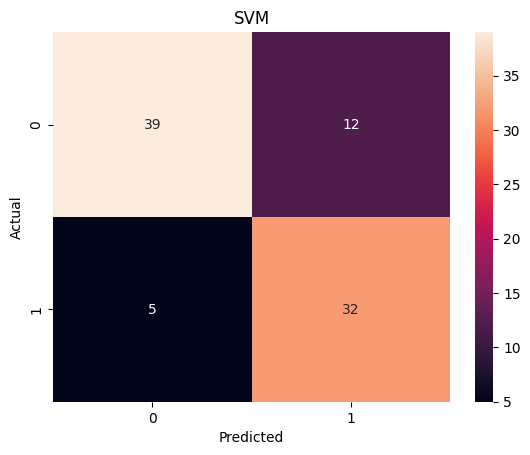

In [58]:
cm_svm = confusion_matrix(y_test, pred_svm)

sns.heatmap(cm_svm, annot=True, fmt='d')
plt.title("SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## K-Nearest Neighbors (KNN)

In [59]:
knn = KNeighborsClassifier()

In [60]:
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [61]:
pred_knn = knn.predict(X_test)

In [62]:
print("KNN Accuracy:", accuracy_score(y_test, pred_knn))
print(classification_report(y_test, pred_knn))

KNN Accuracy: 0.8181818181818182
              precision    recall  f1-score   support

           0       0.87      0.80      0.84        51
           1       0.76      0.84      0.79        37

    accuracy                           0.82        88
   macro avg       0.81      0.82      0.82        88
weighted avg       0.82      0.82      0.82        88



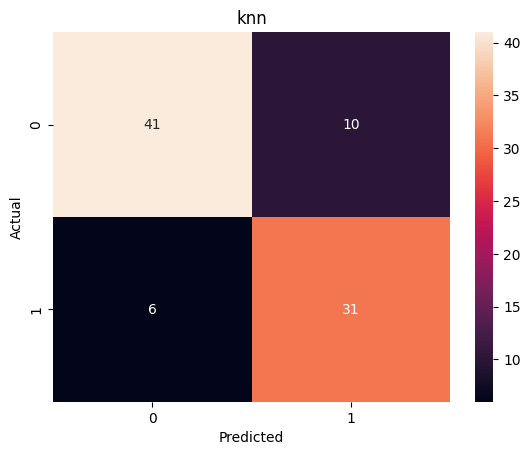

In [63]:
cm_knn = confusion_matrix(y_test, pred_knn)

sns.heatmap(cm_knn, annot=True, fmt='d')
plt.title("knn")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model Comparison

In [64]:
Model_comparison = pd.DataFrame({

"Model":[
"Logistic Regression",
"Decision Tree",
"Random Forest",
"SVM",
"KNN"
],

"Accuracy":[
accuracy_score(y_test,pred_lr),
accuracy_score(y_test,pred_dt),
accuracy_score(y_test,pred_rf),
accuracy_score(y_test,pred_svm),
accuracy_score(y_test,pred_knn)
],

"Precision":[
precision_score(y_test,pred_lr),
precision_score(y_test,pred_dt),
precision_score(y_test,pred_rf),
precision_score(y_test,pred_svm),
precision_score(y_test,pred_knn)
],

"Recall":[
recall_score(y_test,pred_lr),
recall_score(y_test,pred_dt),
recall_score(y_test,pred_rf),
recall_score(y_test,pred_svm),
recall_score(y_test,pred_knn)
],

"F1 Score":[
f1_score(y_test,pred_lr),
f1_score(y_test,pred_dt),
f1_score(y_test,pred_rf),
f1_score(y_test,pred_svm),
f1_score(y_test,pred_knn)
]

})

Model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.795455,0.731707,0.810811,0.769231
1,Decision Tree,0.761364,0.690476,0.783784,0.734177
2,Random Forest,0.852273,0.800000,0.864865,0.831169
3,SVM,0.806818,0.727273,0.864865,0.790123
4,KNN,0.818182,0.756098,0.837838,0.794872


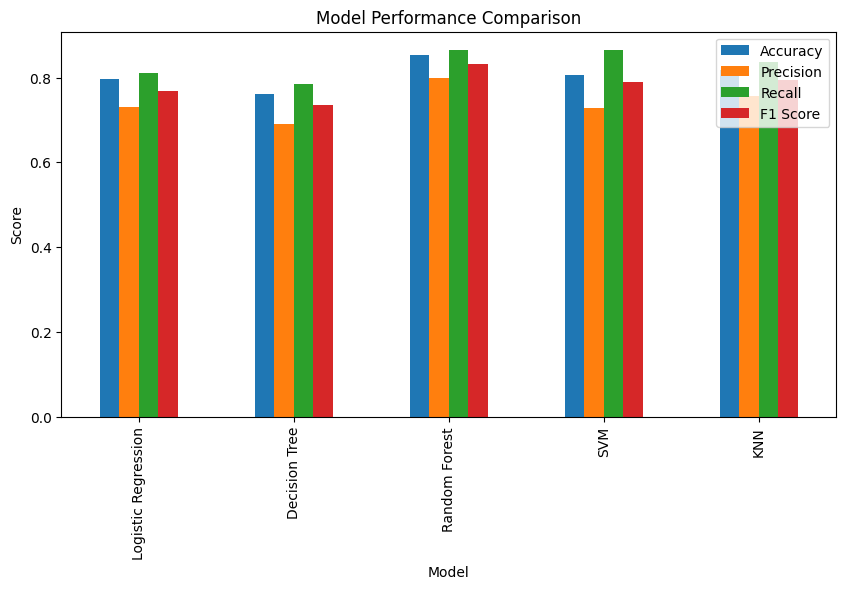

In [65]:
Model_comparison.set_index("Model").plot(kind="bar", figsize=(10,5))

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.show()

###  Final Comparison Insights

- Random Forest → Best overall performance  
- SVM & KNN → Good balanced models  
- Logistic Regression → Decent baseline  
- Decision Tree → Lowest performance  

---

### Key Observation

- Ensemble model (Random Forest) performs best  
- Complex models handle financial data better  


## Voting Classifier (Ensemble Learning)

Voting Classifier combines multiple models to improve prediction performance.

We use:
- Random Forest
- SVM
- KNN

Soft voting is used, where probabilities are averaged.

In [66]:
rf = RandomForestClassifier(random_state=42)
svm = SVC(probability=True)
knn = KNeighborsClassifier()

In [67]:
voting = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('svm', svm),
        ('knn', knn)
    ],
    voting='soft'
)

In [68]:
voting.fit(X_train, y_train)

,estimators,"[('rf', ...), ('svm', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1


In [69]:
pred_vote = voting.predict(X_test)

In [70]:
print("Initial Voting Accuracy:", accuracy_score(y_test, pred_vote))
print(classification_report(y_test, pred_vote))

Initial Voting Accuracy: 0.8181818181818182
              precision    recall  f1-score   support

           0       0.89      0.78      0.83        51
           1       0.74      0.86      0.80        37

    accuracy                           0.82        88
   macro avg       0.82      0.82      0.82        88
weighted avg       0.83      0.82      0.82        88



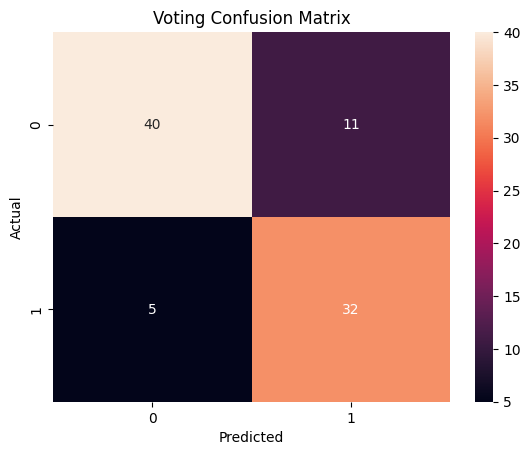

In [72]:
cm_voting = confusion_matrix(y_test, pred_vote)

sns.heatmap(cm_voting, annot=True, fmt='d')
plt.title("Voting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Insights

- Ensemble improves stability  
- Recall is high → good bankruptcy detection  
- Performance is good but not better than Random Forest  

Voting classifier gives balanced performance but does not outperform the best individual model.

## Hyperparameter Tuning (GridSearchCV)

We use GridSearchCV to find the best parameters for models.

Models tuned:
- Random Forest
- SVM
- KNN

This improves model performance by selecting optimal parameters.

In [73]:
param_rf = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

In [74]:
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_rf, cv=3)
grid_rf.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10], 'n_estimators': [50, 100]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [75]:
best_rf = grid_rf.best_estimator_

In [76]:
param_svm = {
    'C': [0.1, 1],
    'kernel': ['linear', 'rbf']
}

In [77]:
grid_svm = GridSearchCV(SVC(probability=True), param_svm, cv=3)
grid_svm.fit(X_train, y_train)

,estimator,SVC(probability=True)
,param_grid,"{'C': [0.1, 1], 'kernel': ['linear', 'rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [78]:
best_svm = grid_svm.best_estimator_

In [79]:
param_knn = {
    'n_neighbors': [3, 5, 7]
}


In [80]:
grid_knn = GridSearchCV(KNeighborsClassifier(), param_knn, cv=3)
grid_knn.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,3


In [81]:
best_knn = grid_knn.best_estimator_

### Insights

- Best parameters selected automatically  
- Improved model generalization  
- Reduced overfitting  

Hyperparameter tuning helps achieve better performance than default models.

## Final Voting Classifier (Tuned Models)

We combine the best-tuned models into a final voting classifier.

This gives the most optimized ensemble model.

In [82]:
voting_final = VotingClassifier(
    estimators=[
        ('rf', best_rf),
        ('svm', best_svm),
        ('knn', best_knn)
    ],
    voting='soft'
)

In [83]:
voting_final.fit(X_train, y_train)

,estimators,"[('rf', ...), ('svm', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,n_estimators,50
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1


In [84]:
pred_final= voting_final.predict(X_test)

In [85]:
print("Voting Accuracy:", accuracy_score(y_test, pred_final))

Voting Accuracy: 0.8409090909090909


In [86]:
print(classification_report(y_test, pred_final))

              precision    recall  f1-score   support

           0       0.89      0.82      0.86        51
           1       0.78      0.86      0.82        37

    accuracy                           0.84        88
   macro avg       0.84      0.84      0.84        88
weighted avg       0.85      0.84      0.84        88



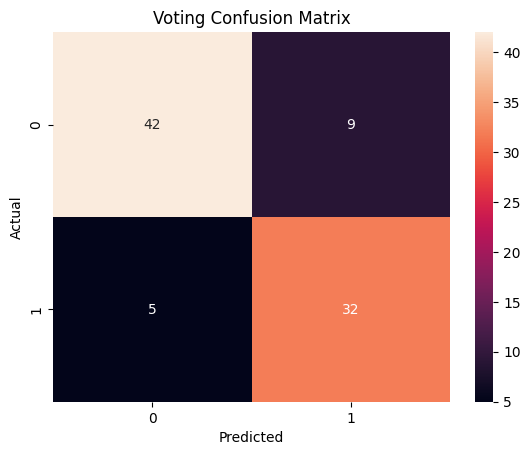

In [87]:
cm = confusion_matrix(y_test, pred_final)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Voting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

###  Insights

- Improved performance after tuning  
- High recall → strong bankruptcy detection  
- Balanced precision and recall  

Tuned Voting Classifier performs better than initial models and is suitable for final prediction.

## best Random Forest Model

We also evaluate the tuned Random Forest model separately.

In [88]:
pred_rf = best_rf.predict(X_test)

In [89]:
print("Final RF Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

Final RF Accuracy: 0.8522727272727273
              precision    recall  f1-score   support

           0       0.90      0.84      0.87        51
           1       0.80      0.86      0.83        37

    accuracy                           0.85        88
   macro avg       0.85      0.85      0.85        88
weighted avg       0.86      0.85      0.85        88



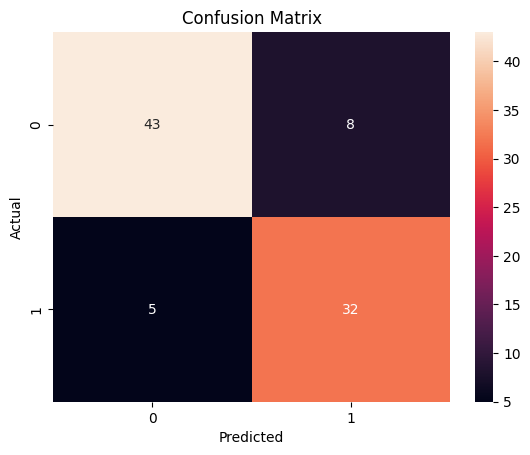

In [90]:
cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


- Still the best performing model  
- Highest accuracy and balanced metrics  

---

###  Final Conclusion

Random Forest remains the best model overall.

## ROC Curve Analysis

ROC Curve evaluates model performance across different thresholds.

AUC (Area Under Curve) indicates model quality.

In [91]:
y_prob = best_rf.predict_proba(X_test)[:, 1]

In [92]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [93]:
roc_auc = auc(fpr, tpr)

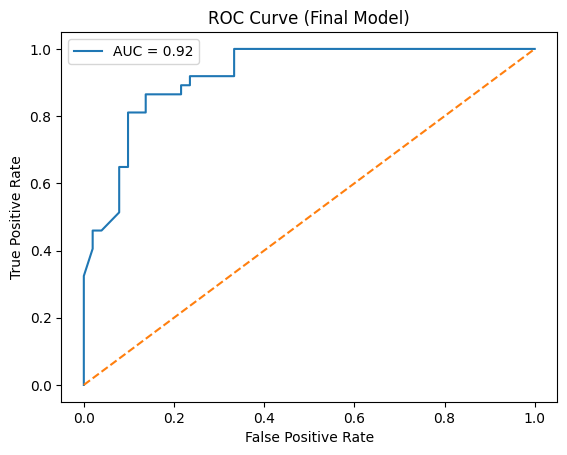

AUC Score: 0.9218335983041865


In [94]:
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Final Model)")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

###  Insights

- AUC close to 1 → excellent model  
- Model distinguishes well between classes  

The model has strong classification capability.

## Cross Validation

Cross-validation ensures model stability and reliability.

We use 5-fold cross validation.

In [95]:
cv_scores = cross_val_score(best_rf, X_res, y_res, cv=5)

print("Mean Accuracy:", cv_scores.mean())

Mean Accuracy: 0.8431818181818181


###  Insights

- Consistent performance across folds  
- Model is stable and reliable  

The model generalizes well to unseen data.

## Feature Importance Analysis

We analyze the importance of features using Random Forest.

This helps us understand which financial indicators contribute most to bankruptcy prediction.

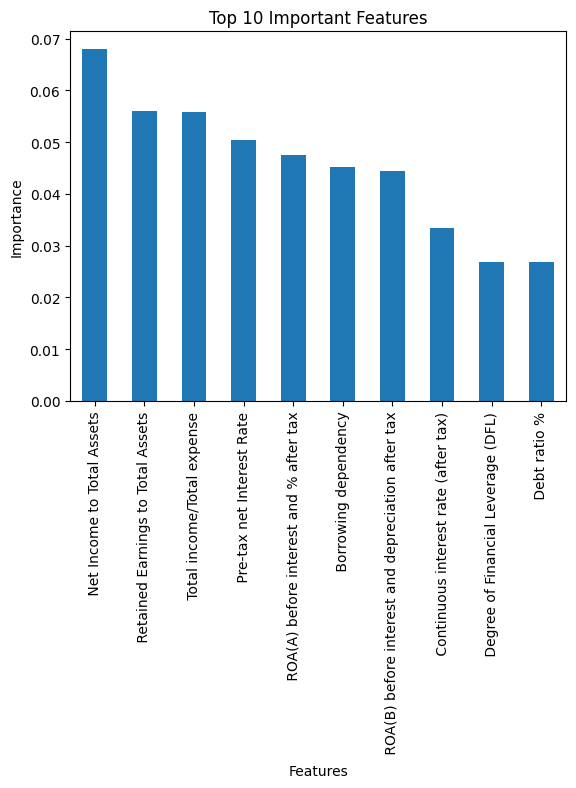

In [96]:
feat_imp = pd.Series(best_rf.feature_importances_, index=X.columns)

feat_imp.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

## SHAP Analysis

SHAP is used to explain how each feature impacts model predictions.

In [97]:
explainer = shap.TreeExplainer(best_rf, X_test)

In [98]:
shap_values = explainer.shap_values(X_test, check_additivity=False)

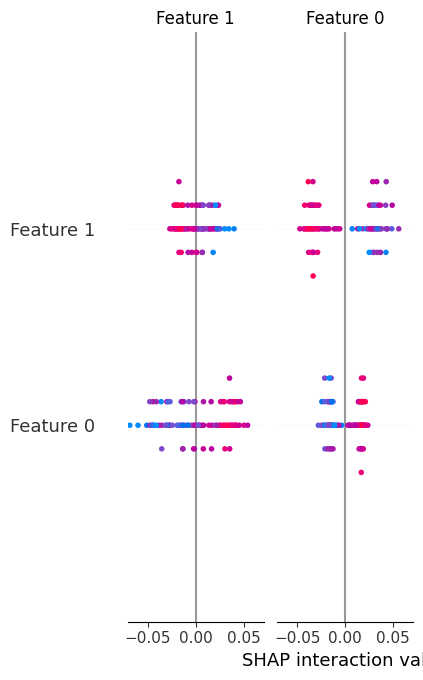

In [99]:
shap.summary_plot(shap_values, X_test)

###  Insights

- Features with higher SHAP values have stronger influence  
- Positive SHAP → increases bankruptcy probability  
- Negative SHAP → decreases bankruptcy probability  

- The model relies heavily on financial ratios  
- Some features increase risk, others reduce it  


## LIME (Local Interpretable Model-Agnostic Explanations)

LIME explains individual predictions.

It shows why a specific company is classified as bankrupt or not.

In [100]:
explainer = LimeTabularExplainer(
    X_train,
    feature_names=X.columns,
    class_names=["Not Bankrupt", "Bankrupt"],
    mode="classification"
)

In [101]:
exp = explainer.explain_instance(
    X_test[0],
    voting.predict_proba
)

display(HTML(exp.as_html()))

###  Insights

- Prediction probability:
  - Bankrupt: 72%
  - Not Bankrupt: 28%

- Key contributing features:
  - Tax rate  
  - EPS  
  - ROA  
  - Retained earnings  

- LIME shows feature-level contribution  
- Helps understand individual decisions  

LIME makes the model decision explainable for real-world use.

## Model Saving

In [103]:
joblib.dump(best_rf, "bankruptcies_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

## Final Project Summary

This project successfully developed a machine learning model to predict company bankruptcy.

### Key Achievements:

- Performed detailed EDA and visualization  
- Handled class imbalance using undersampling  
- Built multiple models and compared performance  
- Selected Random Forest as the best model  
- Improved performance using hyperparameter tuning  
- Achieved high ROC AUC score (0.92)  
- Ensured model reliability using cross-validation  
- Applied SHAP and LIME for explainability  
- Saved model for deployment  

---

###  Final Outcome

A reliable and interpretable model for predicting company bankruptcy.

---

###  Future Scope

- Deploy as web app  
- Use real-time financial data  
- Improve with deep learning models 

## Key Questions Answered
##### 1. Which financial indicators are the most significant predictors of bankruptcy?
Answer:

The most important financial indicators for predicting bankruptcy are:

Net Income to Total Assets

Retained Earnings to Total Assets

Total Income to Total Expense

Pre-tax Net Interest Rate

Debt Ratio

Borrowing Dependency

Profitability-related features are the strongest indicators.
Companies with low profit and weak asset performance are more likely to go bankrupt.

At the same time, high debt and financial leverage increase the risk of bankruptcy.

So, both low profitability and high debt are key signals of bankruptcy.

##### 2. How does the model’s performance compare across different machine learning algorithms?
 Answer:

Different models were tested and compared:

Logistic Regression → ~79% accuracy

Decision Tree → ~76% accuracy

Random Forest → ~85% accuracy (best)

SVM → ~80% accuracy

KNN → ~81% accuracy

Voting Classifier → ~84% accuracy

Random Forest performed the best because it combines multiple decision trees and captures complex relationships in data.

Voting classifier also performed well by combining multiple models, but it did not outperform Random Forest.

Random Forest is the best model due to its high accuracy and balanced performance (precision + recall).

##### 3. What are the potential risks of using the model in real-world decision-making?
 Answer:

There are several risks in using the model:

Data Dependency
The model is trained on historical data and may not perform well in changing market conditions.

False Predictions

False positives → good companies marked as risky

False negatives → risky companies missed

Class Imbalance Issues
Real-world data is often imbalanced, which can affect predictions.

Missing External Factors
The model does not consider:

Market conditions

Economic changes

Management decisions

Overfitting Risk
Complex models may not generalize well.